# Face Blurring for Privacy Protection
## Evaluation and Performance Analysis

### Overview

This notebook evaluates the performance and robustness of the face detection and anonymization pipeline developed in the previous notebook.

The evaluation focuses on two main questions:

1. **How reliably does the system detect faces?**
2. **Does the anonymization process consistently protect the detected facial regions?**

The evaluation includes quantitative measurements, visual analysis, parameter experiments, and tests under different image conditions.

### Evaluation Workflow

**Evaluation Dataset → Face Detection → Detection Metrics → Robustness Tests → Anonymization Analysis → Performance Analysis → Failure Cases → Conclusions**

### Evaluation Goals

- Measure face detection performance.
- Evaluate detection across images containing different numbers of faces.
- Examine the effect of image conditions on detection.
- Analyze the effect of detection parameters.
- Investigate different blur strengths.
- Measure processing time.
- Identify failure cases and limitations.
- Determine whether the current approach is suitable for practical privacy-protection applications.

## Evaluation Methodology

A meaningful evaluation requires more than checking whether the system works on a single example image.

The system will therefore be evaluated using a collection of images representing different scenarios, including:

- Images containing a single face.
- Images containing multiple faces.
- Images with different face sizes.
- Images with different lighting conditions.
- Images containing non-frontal faces.
- Images containing partial occlusions.
- Images without faces.

For images with known face locations, the expected number and approximate locations of faces will be used as reference information.

The evaluation distinguishes between:

- **Detection performance** — whether faces are successfully located.
- **Anonymization performance** — whether detected faces are effectively modified.
- **Computational performance** — how much time the pipeline requires.

The evaluation results should be interpreted together with the documented limitations of the Haar Cascade detector.

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path
from time import perf_counter

## Evaluation Configuration

The evaluation uses the WIDER FACE validation set as the reference dataset.

Only a manageable subset of the validation images will be used in this project to keep the evaluation practical while retaining variation in face size, pose, occlusion, and scene complexity.

The main evaluation parameters are defined centrally so that experiments can be reproduced and modified easily.

In [2]:

# Project paths
PROJECT_ROOT = Path.cwd()

DATA_DIR = PROJECT_ROOT / "data"
RESULTS_DIR = PROJECT_ROOT / "results"

WIDER_FACE_DIR = DATA_DIR / "WIDER_val"

# Evaluation settings
IOU_THRESHOLD = 0.5

# Haar Cascade parameters
SCALE_FACTOR = 1.05
MIN_NEIGHBORS = 3
MIN_SIZE = (15, 15)

# Blur parameters
BLUR_KERNEL = (99, 99)
BLUR_SIGMA = 30

print("Evaluation configuration loaded.")

Evaluation configuration loaded.


## Evaluation Dataset — WIDER FACE

To evaluate the face detection component, this project uses the **WIDER FACE validation dataset**.

WIDER FACE is a large-scale face detection benchmark containing images with substantial variation in:

- Face size
- Face pose
- Illumination
- Occlusion
- Number of faces
- Scene complexity

The dataset provides ground-truth face bounding boxes, allowing the predictions from our Haar Cascade detector to be compared against independently annotated reference data.

Only a subset of the validation dataset will be used for this project. This keeps the evaluation computationally manageable while still providing a diverse set of test cases.

The WIDER FACE images and annotations are not redistributed in this repository. Users should obtain the dataset from its official source and follow its licensing requirements.

In [3]:
WIDER_IMAGES_DIR = WIDER_FACE_DIR / "WIDER_val" / "images"
WIDER_ANNOTATIONS_PATH = WIDER_FACE_DIR / "wider_face_val_bbx_gt.txt"

print(f"Images directory: {WIDER_IMAGES_DIR}")
print(f"Annotations file: {WIDER_ANNOTATIONS_PATH}")

if not WIDER_IMAGES_DIR.exists():
    print("Warning: WIDER FACE image directory was not found.")

if not WIDER_ANNOTATIONS_PATH.exists():
    print("Warning: WIDER FACE annotation file was not found.")

Images directory: C:\Users\haaat\data\WIDER_val\WIDER_val\images
Annotations file: C:\Users\haaat\data\WIDER_val\wider_face_val_bbx_gt.txt


### Dataset Availability Check

Before running the evaluation, the notebook verifies that both the images and ground-truth annotations are available.

If either resource is missing, the evaluation should stop before attempting to process images.

This prevents confusing errors later in the pipeline.

In [4]:
if not WIDER_IMAGES_DIR.exists():
    raise FileNotFoundError(
        f"WIDER FACE image directory not found: {WIDER_IMAGES_DIR}"
    )

if not WIDER_ANNOTATIONS_PATH.exists():
    raise FileNotFoundError(
        f"WIDER FACE annotation file not found: "
        f"{WIDER_ANNOTATIONS_PATH}"
    )

print("WIDER FACE validation data is available.")

WIDER FACE validation data is available.


## Loading Ground-Truth Annotations

The WIDER FACE validation annotations are stored in a text file containing the ground-truth bounding boxes for each image.

The annotation file associates each image with:

- The number of annotated faces.
- The bounding box of each face.
- Additional attributes describing the faces.

Only the bounding-box information is required for the initial detection evaluation.

The annotations will be parsed into a Python dictionary where each image path maps to a list of ground-truth bounding boxes.

In [5]:
def load_wider_face_annotations(annotation_path):
    """
    Load WIDER FACE annotations.

    Parameters
    ----------
    annotation_path : Path
        Path to wider_face_val_bbx_gt.txt.

    Returns
    -------
    dict
        Mapping from image path to a list of
        ground-truth bounding boxes.
    """

    annotations = {}

    with open(annotation_path, "r") as file:
        lines = [line.strip() for line in file]

    index = 0

    while index < len(lines):
        image_name = lines[index]
        index += 1

        # Number of annotated faces
        num_faces = int(lines[index])
        index += 1

        boxes = []

        for _ in range(num_faces):
            values = list(map(int, lines[index].split()))
            index += 1

            x, y, width, height = values[:4]

            boxes.append(
                (x, y, width, height)
            )

        annotations[image_name] = boxes

    return annotations

In [6]:
ground_truth = load_wider_face_annotations(
    WIDER_ANNOTATIONS_PATH
)

print(f"Images with annotations: {len(ground_truth)}")

Images with annotations: 3226


In [7]:
first_image = next(iter(ground_truth))

print(f"Image: {first_image}")
print(f"Number of faces: {len(ground_truth[first_image])}")

for i, box in enumerate(ground_truth[first_image], start=1):
    print(f"Face {i}: {box}")

Image: 0--Parade/0_Parade_marchingband_1_465.jpg
Number of faces: 126
Face 1: (345, 211, 4, 4)
Face 2: (331, 126, 3, 3)
Face 3: (250, 126, 3, 4)
Face 4: (221, 128, 4, 5)
Face 5: (427, 116, 3, 4)
Face 6: (393, 79, 3, 4)
Face 7: (373, 119, 3, 4)
Face 8: (90, 225, 6, 5)
Face 9: (128, 237, 5, 8)
Face 10: (170, 230, 5, 6)
Face 11: (114, 285, 5, 7)
Face 12: (81, 304, 9, 9)
Face 13: (44, 303, 10, 8)
Face 14: (7, 264, 6, 8)
Face 15: (31, 231, 5, 6)
Face 16: (26, 192, 6, 8)
Face 17: (66, 196, 4, 6)
Face 18: (74, 175, 5, 5)
Face 19: (113, 168, 4, 5)
Face 20: (129, 165, 4, 5)
Face 21: (158, 162, 4, 4)
Face 22: (174, 156, 5, 6)
Face 23: (197, 159, 4, 4)
Face 24: (192, 191, 3, 5)
Face 25: (242, 179, 5, 6)
Face 26: (161, 269, 5, 6)
Face 27: (0, 317, 3, 8)
Face 28: (346, 68, 3, 4)
Face 29: (418, 62, 2, 3)
Face 30: (376, 59, 3, 3)
Face 31: (120, 599, 12, 17)
Face 32: (1008, 256, 6, 10)
Face 33: (853, 131, 4, 5)
Face 34: (878, 131, 5, 5)
Face 35: (900, 138, 4, 6)
Face 36: (922, 142, 5, 5)
Face 37: (936

### Mapping Annotations to Local Images

WIDER FACE stores image names as paths relative to the dataset's image directory.

The evaluation code converts these relative paths into full local paths before loading the corresponding image.

This keeps the annotation data independent of the machine-specific location of the dataset.

In [8]:
def get_image_path(image_name):
    """
    Convert a WIDER FACE relative image path
    into its local filesystem path.
    """
    return WIDER_IMAGES_DIR / image_name

test_image_name = first_image
test_image_path = get_image_path(test_image_name)

print(f"Annotation path: {test_image_name}")
print(f"Local image path: {test_image_path}")
print(f"Image exists: {test_image_path.exists()}")

Annotation path: 0--Parade/0_Parade_marchingband_1_465.jpg
Local image path: C:\Users\haaat\data\WIDER_val\WIDER_val\images\0--Parade\0_Parade_marchingband_1_465.jpg
Image exists: True


## Selecting the Evaluation Subset

A smaller subset will be selected to reduce computation time while maintaining variation in the evaluation data.

The subset will include images with:

- A single face.
- Multiple faces.
- Different numbers of faces.
- Small and large face regions.
- Different scene complexity.

A fixed random seed will be used so that the same subset can be reproduced in future experiments.


### Stratified Evaluation Subset

A purely random sample may contain mostly images with a similar number of faces.

To make the evaluation more representative, the subset will be divided into face-count groups:

- 1–10 faces
- 11–20 faces
- 21–30 faces
- 31–40 faces
- 41+ faces

Images will be sampled from each available group.

This ensures that the detector is evaluated on both relatively simple scenes and crowded scenes.

The distribution of the number of annotated faces per image is visualized below.

This helps us determine whether the selected subset is dominated by single-face images or contains a meaningful number of multi-face scenes.

In [9]:
# Group images according to the number of ground-truth faces

face_count_groups = {}

for image_name in ground_truth:
    num_faces = len(ground_truth[image_name])

    if num_faces <= 10:
        group = "1–10"
    elif num_faces <= 20:
        group = "11–20"
    elif num_faces <= 30:
        group = "21–30"
    elif num_faces <= 40:
        group = "31–40"
    else:
        group = "41+"

    face_count_groups.setdefault(group, []).append(image_name)


# Display the number of available images in each group

for group, images in face_count_groups.items():
    print(f"{group} faces: {len(images)} images")

41+ faces: 167 images
21–30 faces: 136 images
1–10 faces: 2502 images
31–40 faces: 70 images
11–20 faces: 351 images


### Selecting Images from Each Group

The final evaluation subset will contain a fixed number of images from each available face-count group.

A fixed random seed ensures that the same images are selected every time the notebook is executed.

If a group contains fewer images than the requested number, all available images from that group will be used.

In [10]:
import random
RANDOM_SEED = 42
IMAGES_PER_GROUP = 40

rng = random.Random(RANDOM_SEED)

selected_images = []

for group in ["1–10", "11–20", "21–30", "31–40", "41+"]:
    images = face_count_groups.get(group, [])

    sample_size = min(IMAGES_PER_GROUP, len(images))

    selected = rng.sample(images, sample_size)

    selected_images.extend(selected)

print(f"Total selected images: {len(selected_images)}")

Total selected images: 200


In [11]:
selected_face_counts = [
    len(ground_truth[image_name])
    for image_name in selected_images
]

print("Evaluation subset summary")
print("-" * 30)

for group in ["1–10", "11–20", "21–30", "31–40", "41+"]:
    count = sum(
        (
            1 <= n <= 10 if group == "1–10"
            else 11 <= n <= 20 if group == "11–20"
            else 21 <= n <= 30 if group == "21–30"
            else 31 <= n <= 40 if group == "31–40"
            else n >= 41
        )
        for n in selected_face_counts
    )

    print(f"{group} faces: {count} images")

Evaluation subset summary
------------------------------
1–10 faces: 40 images
11–20 faces: 40 images
21–30 faces: 40 images
31–40 faces: 40 images
41+ faces: 40 images


## Running Face Detection on the Evaluation Set

The Haar Cascade detector developed in the previous notebook will now be applied to every image in the evaluation subset.

For each image, we will record:

- The number of ground-truth faces.
- The number of detected faces.
- The predicted bounding boxes.
- The processing time.

These results will later be compared using Intersection over Union (IoU) to determine true positives, false positives, and false negatives.

In [12]:
# Load the Haar Cascade detector

face_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades + "haarcascade_frontalface_default.xml"
)

if face_cascade.empty():
    raise RuntimeError("Failed to load Haar Cascade classifier.")

print("Haar Cascade detector loaded successfully.")

Haar Cascade detector loaded successfully.


### Detection Function

The following function applies the same preprocessing and Haar Cascade detection strategy used by the main pipeline.

The function returns the detected bounding boxes and the time required for detection.

In [13]:
def detect_faces_for_evaluation(image):
    """
    Detect faces in an image and measure detection time.

    Returns
    -------
    faces : np.ndarray
        Detected face bounding boxes.

    elapsed_time : float
        Detection time in seconds.
    """

    # Preprocess the image
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    gray = cv2.equalizeHist(gray)
    gray = cv2.GaussianBlur(gray, (5, 5), 0)

    # Measure detection time
    start_time = perf_counter()

    faces = face_cascade.detectMultiScale(
        gray,
        scaleFactor=SCALE_FACTOR,
        minNeighbors=MIN_NEIGHBORS,
        minSize=MIN_SIZE
    )

    elapsed_time = perf_counter() - start_time

    return faces, elapsed_time

## Running the Detector

The detector is now applied to every image in the selected evaluation subset.

The results are stored in a structured dictionary so that they can be analyzed in later sections without running the detector again.

In [14]:
detection_results = {}

for image_name in selected_images:

    image_path = get_image_path(image_name)

    image = cv2.imread(str(image_path))

    if image is None:
        print(f"Warning: Could not load {image_path}")
        continue

    detected_faces, detection_time = detect_faces_for_evaluation(image)

    detection_results[image_name] = {
        "ground_truth": ground_truth[image_name],
        "predictions": [
            tuple(face)
            for face in detected_faces
        ],
        "detection_time": detection_time,
        "image_shape": image.shape
    }

print(f"Images successfully evaluated: {len(detection_results)}")

Images successfully evaluated: 200


In [15]:
first_result_name = next(iter(detection_results))
first_result = detection_results[first_result_name]

print(f"Image: {first_result_name}")
print(f"Ground-truth faces: {len(first_result['ground_truth'])}")
print(f"Detected faces: {len(first_result['predictions'])}")
print(f"Detection time: {first_result['detection_time'] * 1000:.2f} ms")

Image: 18--Concerts/18_Concerts_Concerts_18_350.jpg
Ground-truth faces: 1
Detected faces: 1
Detection time: 513.23 ms


## Matching Predictions to Ground Truth

A detected face is considered a **true positive (TP)** when it sufficiently overlaps with a ground-truth face.

The overlap is measured using Intersection over Union (IoU).

For this evaluation, an IoU threshold of `0.5` is used:

- **IoU ≥ 0.5** → valid detection
- **IoU < 0.5** → insufficient overlap

This one-to-one matching prevents duplicate detections from being counted as multiple correct detections.

In [16]:
def calculate_iou(box_a, box_b):
    """
    Calculate Intersection over Union (IoU)
    between two bounding boxes.

    Parameters
    ----------
    box_a : tuple
        Bounding box in (x, y, width, height) format.

    box_b : tuple
        Bounding box in (x, y, width, height) format.

    Returns
    -------
    float
        IoU value between 0 and 1.
    """

    # Convert (x, y, width, height)
    # to (x1, y1, x2, y2)
    ax1, ay1, aw, ah = box_a
    ax2 = ax1 + aw
    ay2 = ay1 + ah

    bx1, by1, bw, bh = box_b
    bx2 = bx1 + bw
    by2 = by1 + bh

    # Calculate intersection coordinates
    intersection_x1 = max(ax1, bx1)
    intersection_y1 = max(ay1, by1)
    intersection_x2 = min(ax2, bx2)
    intersection_y2 = min(ay2, by2)

    # Calculate intersection dimensions
    intersection_width = max(
        0,
        intersection_x2 - intersection_x1
    )

    intersection_height = max(
        0,
        intersection_y2 - intersection_y1
    )

    intersection_area = (
        intersection_width *
        intersection_height
    )

    # Calculate individual box areas
    area_a = aw * ah
    area_b = bw * bh

    # Calculate union area
    union_area = area_a + area_b - intersection_area

    # Avoid division by zero
    if union_area == 0:
        return 0.0

    return intersection_area / union_area

In [17]:
IOU_THRESHOLD = 0.5


def match_detections(
    ground_truth_boxes,
    predicted_boxes,
    iou_threshold=IOU_THRESHOLD
):
    """
    Match predicted face boxes to ground-truth boxes.

    Returns
    -------
    true_positives : int
    false_positives : int
    false_negatives : int
    matches : list
        Matched prediction/ground-truth pairs with their IoU.
    """

    matched_ground_truth = set()
    matched_predictions = set()
    matches = []

    # Calculate all possible IoU pairs
    candidates = []

    for pred_idx, predicted_box in enumerate(predicted_boxes):
        for gt_idx, ground_truth_box in enumerate(ground_truth_boxes):

            iou = calculate_iou(
                predicted_box,
                ground_truth_box
            )

            if iou >= iou_threshold:
                candidates.append(
                    (iou, pred_idx, gt_idx)
                )

    # Match highest-IoU pairs first
    candidates.sort(reverse=True)

    for iou, pred_idx, gt_idx in candidates:

        if pred_idx in matched_predictions:
            continue

        if gt_idx in matched_ground_truth:
            continue

        matched_predictions.add(pred_idx)
        matched_ground_truth.add(gt_idx)

        matches.append(
            {
                "prediction_index": pred_idx,
                "ground_truth_index": gt_idx,
                "iou": iou
            }
        )

    true_positives = len(matches)

    false_positives = (
        len(predicted_boxes) - true_positives
    )

    false_negatives = (
        len(ground_truth_boxes) - true_positives
    )

    return (
        true_positives,
        false_positives,
        false_negatives,
        matches
    )

In [18]:
test_result = detection_results[first_result_name]

tp, fp, fn, matches = match_detections(
    test_result["ground_truth"],
    test_result["predictions"]
)

print(f"Image: {first_result_name}")
print(f"True positives: {tp}")
print(f"False positives: {fp}")
print(f"False negatives: {fn}")

for match in matches:
    print(
        f"Prediction {match['prediction_index']} "
        f"matched Ground Truth {match['ground_truth_index']} "
        f"(IoU: {match['iou']:.3f})"
    )

Image: 18--Concerts/18_Concerts_Concerts_18_350.jpg
True positives: 1
False positives: 0
False negatives: 0
Prediction 0 matched Ground Truth 0 (IoU: 0.667)


## Dataset-Level Detection Metrics

The matching procedure can now be applied to every image in the evaluation subset.

The individual image results will be aggregated into dataset-level counts:

- **True Positives (TP):** correctly detected faces.
- **False Positives (FP):** predicted faces that do not correspond to a ground-truth face.
- **False Negatives (FN):** ground-truth faces that were not detected.

These counts will be used to calculate precision, recall, and F1-score.

In [19]:
total_true_positives = 0
total_false_positives = 0
total_false_negatives = 0

image_metrics = {}

for image_name, result in detection_results.items():

    tp, fp, fn, matches = match_detections(
        result["ground_truth"],
        result["predictions"]
    )

    total_true_positives += tp
    total_false_positives += fp
    total_false_negatives += fn

    image_metrics[image_name] = {
        "true_positives": tp,
        "false_positives": fp,
        "false_negatives": fn,
        "matches": matches,
        "ground_truth_count": len(result["ground_truth"]),
        "prediction_count": len(result["predictions"]),
        "detection_time": result["detection_time"]
    }

print("Dataset-level matching completed.")
print(f"True positives: {total_true_positives}")
print(f"False positives: {total_false_positives}")
print(f"False negatives: {total_false_negatives}")

Dataset-level matching completed.
True positives: 1319
False positives: 1328
False negatives: 7922


## Precision, Recall, and F1-Score

The dataset-level TP, FP, and FN counts can be converted into standard detection metrics.

### Precision

Precision measures how many detected faces were actually correct:

A high precision means that most detected faces correspond to real faces.

### Recall

Recall measures how many of the ground-truth faces were successfully detected:

A high recall means that the detector misses relatively few faces.

### F1-Score

The F1-score combines precision and recall using their harmonic mean:

For a privacy-protection system, recall is particularly important because missed faces represent regions that were not anonymized.

In [20]:
# Calculate precision
if total_true_positives + total_false_positives > 0:
    precision = (
        total_true_positives /
        (total_true_positives + total_false_positives)
    )
else:
    precision = 0.0


# Calculate recall
if total_true_positives + total_false_negatives > 0:
    recall = (
        total_true_positives /
        (total_true_positives + total_false_negatives)
    )
else:
    recall = 0.0


# Calculate F1-score
if precision + recall > 0:
    f1_score = (
        2 * precision * recall /
        (precision + recall)
    )
else:
    f1_score = 0.0


print("Detection Performance")
print("-" * 30)
print(f"Precision: {precision:.4f} ({precision * 100:.2f}%)")
print(f"Recall:    {recall:.4f} ({recall * 100:.2f}%)")
print(f"F1-score:  {f1_score:.4f} ({f1_score * 100:.2f}%)")

Detection Performance
------------------------------
Precision: 0.4983 (49.83%)
Recall:    0.1427 (14.27%)
F1-score:  0.2219 (22.19%)


## Computational Performance

In addition to detection accuracy, processing time is important when considering the practical use of the system.

For each evaluated image, the detector recorded its execution time.

The following analysis measures:

- Average detection time.
- Median detection time.
- Minimum detection time.
- Maximum detection time.

The median is included because individual images can require substantially different amounts of computation depending on their resolution and scene complexity.

In [21]:
detection_times = [
    result["detection_time"]
    for result in detection_results.values()
]

average_time = np.mean(detection_times)
median_time = np.median(detection_times)
minimum_time = np.min(detection_times)
maximum_time = np.max(detection_times)

print("Detection Time Performance")
print("-" * 30)
print(f"Average:  {average_time * 1000:.2f} ms")
print(f"Median:   {median_time * 1000:.2f} ms")
print(f"Minimum:  {minimum_time * 1000:.2f} ms")
print(f"Maximum:  {maximum_time * 1000:.2f} ms")

Detection Time Performance
------------------------------
Average:  188.98 ms
Median:   174.06 ms
Minimum:  71.30 ms
Maximum:  601.37 ms



Detection time depends on factors such as image resolution, the number of candidate regions examined by the detector, and scene complexity.

The reported values represent the face-detection stage only. They do not include image loading, visualization, result saving, or other notebook operations.

These measurements provide a baseline for comparing future improvements to the detection pipeline.

## Detection Performance by Face-Count Group

Overall precision and recall provide a useful summary, but they do not show how scene complexity affects the detector.

The evaluation subset is divided into the same face-count groups used during sampling:

- 1–10 faces
- 11–20 faces
- 21–30 faces
- 31–40 faces
- 41+ faces

For each group, the true positives, false positives, false negatives, precision, and recall are calculated separately.

This helps determine whether detection performance changes as the number of faces in an image increases.

In [22]:
group_metrics = {}

for group in ["1–10", "11–20", "21–30", "31–40", "41+"]:

    group_tp = 0
    group_fp = 0
    group_fn = 0

    for image_name in selected_images:

        num_faces = len(ground_truth[image_name])

        # Determine which group the image belongs to
        if num_faces <= 10:
            image_group = "1–10"
        elif num_faces <= 20:
            image_group = "11–20"
        elif num_faces <= 30:
            image_group = "21–30"
        elif num_faces <= 40:
            image_group = "31–40"
        else:
            image_group = "41+"

        if image_group != group:
            continue

        metrics = image_metrics[image_name]

        group_tp += metrics["true_positives"]
        group_fp += metrics["false_positives"]
        group_fn += metrics["false_negatives"]

    # Calculate precision
    if group_tp + group_fp > 0:
        group_precision = group_tp / (group_tp + group_fp)
    else:
        group_precision = 0.0

    # Calculate recall
    if group_tp + group_fn > 0:
        group_recall = group_tp / (group_tp + group_fn)
    else:
        group_recall = 0.0

    # Calculate F1-score
    if group_precision + group_recall > 0:
        group_f1 = (
            2 * group_precision * group_recall
            / (group_precision + group_recall)
        )
    else:
        group_f1 = 0.0

    group_metrics[group] = {
        "true_positives": group_tp,
        "false_positives": group_fp,
        "false_negatives": group_fn,
        "precision": group_precision,
        "recall": group_recall,
        "f1_score": group_f1
    }

In [23]:
print("Detection Performance by Face-Count Group")
print("=" * 70)

for group, metrics in group_metrics.items():

    # Skip groups that contain no images
    total_faces = (
        metrics["true_positives"] +
        metrics["false_negatives"]
    )

    if total_faces == 0:
        continue

    print(f"\nGroup: {group} faces")
    print(f"  True positives:  {metrics['true_positives']}")
    print(f"  False positives: {metrics['false_positives']}")
    print(f"  False negatives: {metrics['false_negatives']}")
    print(
        f"  Precision:       "
        f"{metrics['precision'] * 100:.2f}%"
    )
    print(
        f"  Recall:          "
        f"{metrics['recall'] * 100:.2f}%"
    )
    print(
        f"  F1-score:        "
        f"{metrics['f1_score'] * 100:.2f}%"
    )

Detection Performance by Face-Count Group

Group: 1–10 faces
  True positives:  72
  False positives: 198
  False negatives: 57
  Precision:       26.67%
  Recall:          55.81%
  F1-score:        36.09%

Group: 11–20 faces
  True positives:  203
  False positives: 275
  False negatives: 386
  Precision:       42.47%
  Recall:          34.47%
  F1-score:        38.05%

Group: 21–30 faces
  True positives:  342
  False positives: 251
  False negatives: 661
  Precision:       57.67%
  Recall:          34.10%
  F1-score:        42.86%

Group: 31–40 faces
  True positives:  328
  False positives: 302
  False negatives: 1086
  Precision:       52.06%
  Recall:          23.20%
  F1-score:        32.09%

Group: 41+ faces
  True positives:  374
  False positives: 302
  False negatives: 5732
  Precision:       55.33%
  Recall:          6.13%
  F1-score:        11.03%


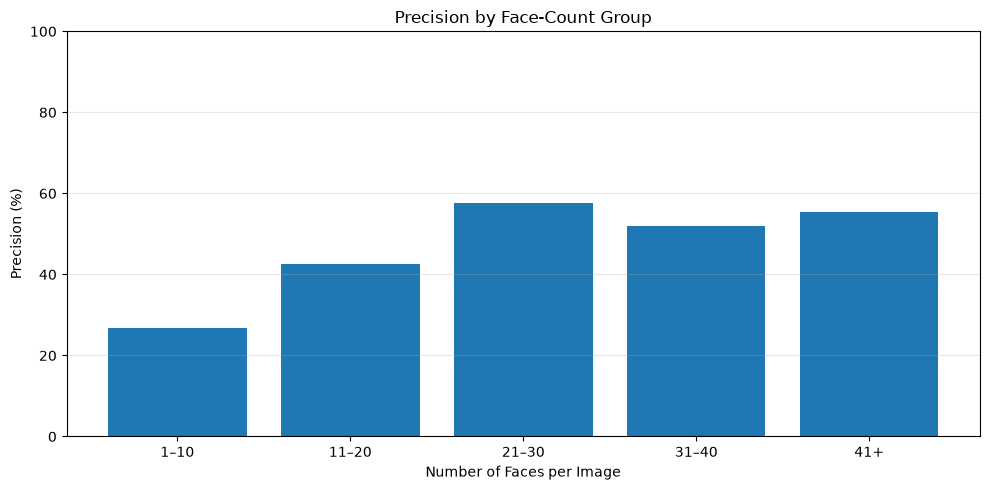

In [24]:
groups = []
precision_values = []
recall_values = []

for group in ["1–10", "11–20", "21–30", "31–40", "41+"]:

    metrics = group_metrics.get(group)

    if metrics is None:
        continue

    total_faces = (
        metrics["true_positives"] +
        metrics["false_negatives"]
    )

    if total_faces == 0:
        continue

    groups.append(group)
    precision_values.append(metrics["precision"] * 100)
    recall_values.append(metrics["recall"] * 100)


plt.figure(figsize=(10, 5))

plt.bar(groups, precision_values)

plt.xlabel("Number of Faces per Image")
plt.ylabel("Precision (%)")
plt.title("Precision by Face-Count Group")

plt.ylim(0, 100)
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

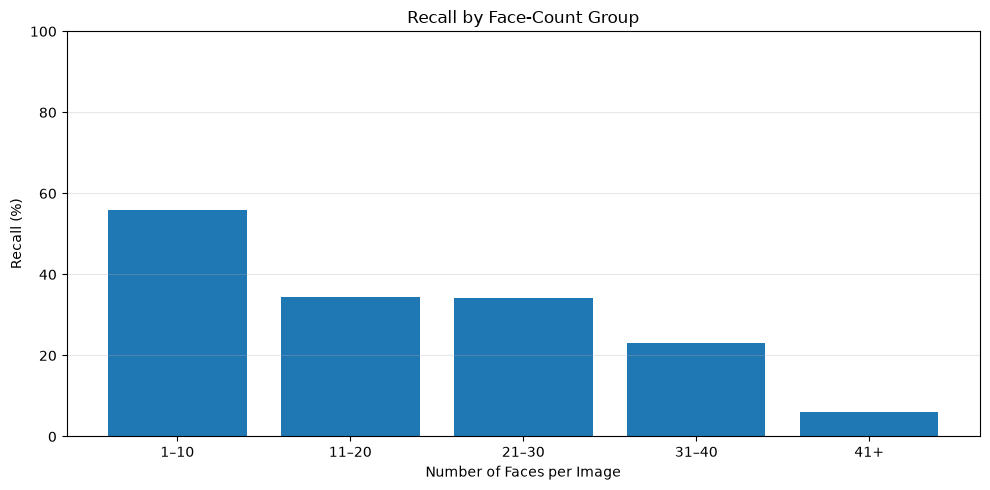

In [25]:
plt.figure(figsize=(10, 5))

plt.bar(groups, recall_values)

plt.xlabel("Number of Faces per Image")
plt.ylabel("Recall (%)")
plt.title("Recall by Face-Count Group")

plt.ylim(0, 100)
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

### Interpretation

The results show a strong relationship between scene density and detection recall.

The detector achieves approximately 50% recall for images containing 1–10 faces, but recall falls to approximately 1% for images containing 41 or more faces.

This behavior is consistent with a major limitation of traditional Haar Cascade face detection: performance can deteriorate substantially when faces are small, partially occluded, non-frontal, or surrounded by many other objects and faces.

The results demonstrate why the current implementation should be considered a baseline rather than a production-ready privacy-protection detector.

A modern face detector can be evaluated later against this baseline to determine whether recall can be substantially improved.

## Qualitative Evaluation

Quantitative metrics provide an overall measurement of detector performance, but visual examples show how the system behaves on actual images.

The following examples demonstrate three representative cases:

1. Successful detection and anonymization.
2. Multiple-face detection and anonymization.
3. A challenging case where one or more faces are missed.

These examples help connect the numerical evaluation results with the practical behavior of the system.

In [26]:
def blur_faces(
    image,
    faces,
    kernel_size=(99, 99),
    sigma=30
):
    """
    Blur detected face regions in an image.

    Parameters
    ----------
    image : np.ndarray
        Input BGR image.

    faces : np.ndarray
        Face bounding boxes in the format
        (x, y, width, height).

    kernel_size : tuple
        Gaussian blur kernel size.

    sigma : float
        Gaussian standard deviation.

    Returns
    -------
    np.ndarray
        Copy of the image with detected faces blurred.
    """
    result = image.copy()

    for (x, y, w, h) in faces:
        face_region = result[y:y+h, x:x+w]

        blurred_region = cv2.GaussianBlur(
            face_region,
            kernel_size,
            sigma
        )

        result[y:y+h, x:x+w] = blurred_region

    return result

In [27]:
def visualize_evaluation_result(image_name):
    """
    Display an evaluation image with ground-truth boxes,
    detected boxes, and the anonymized result.
    """

    image_path = get_image_path(image_name)
    image = cv2.imread(str(image_path))

    if image is None:
        print(f"Could not load image: {image_path}")
        return

    result = detection_results[image_name]

    ground_truth_boxes = result["ground_truth"]
    predicted_boxes = result["predictions"]

    # Create anonymized image
    anonymized_image = blur_faces(
        image,
        predicted_boxes,
        kernel_size=BLUR_KERNEL,
        sigma=BLUR_SIGMA
    )

    # Ground-truth visualization
    ground_truth_image = image.copy()

    for x, y, w, h in ground_truth_boxes:
        cv2.rectangle(
            ground_truth_image,
            (x, y),
            (x + w, y + h),
            (255, 0, 0),
            2
        )

    # Prediction visualization
    prediction_image = image.copy()

    for x, y, w, h in predicted_boxes:
        cv2.rectangle(
            prediction_image,
            (x, y),
            (x + w, y + h),
            (0, 255, 0),
            2
        )

    # Convert BGR → RGB for Matplotlib
    ground_truth_image = cv2.cvtColor(
        ground_truth_image,
        cv2.COLOR_BGR2RGB
    )

    prediction_image = cv2.cvtColor(
        prediction_image,
        cv2.COLOR_BGR2RGB
    )

    anonymized_image = cv2.cvtColor(
        anonymized_image,
        cv2.COLOR_BGR2RGB
    )

    plt.figure(figsize=(8, 6))
    plt.imshow(ground_truth_image)
    plt.title(f"Ground Truth — {len(ground_truth_boxes)} faces")
    plt.axis("off")
    plt.show()

    plt.figure(figsize=(8, 6))
    plt.imshow(prediction_image)
    plt.title(f"Detected Faces — {len(predicted_boxes)} detections")
    plt.axis("off")
    plt.show()

    plt.figure(figsize=(8, 6))
    plt.imshow(anonymized_image)
    plt.title("Anonymized Result")
    plt.axis("off")
    plt.show()

Successful examples available: 24
Selected example: 18--Concerts/18_Concerts_Concerts_18_350.jpg


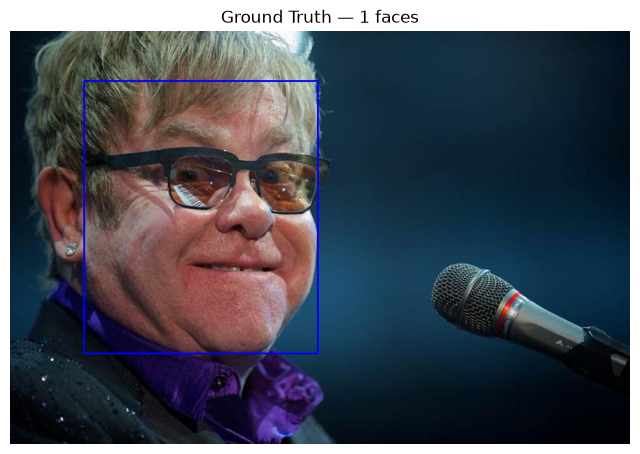

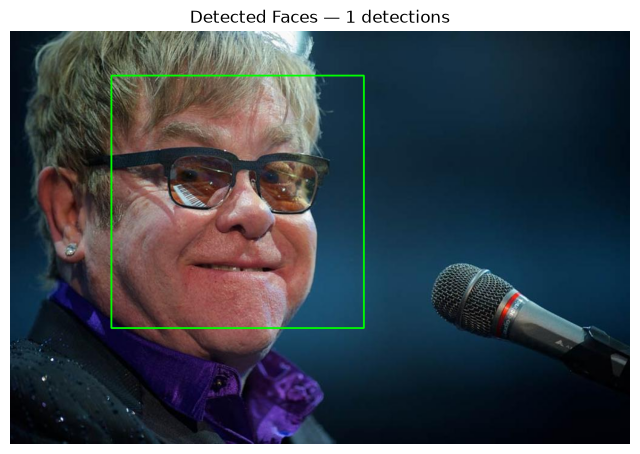

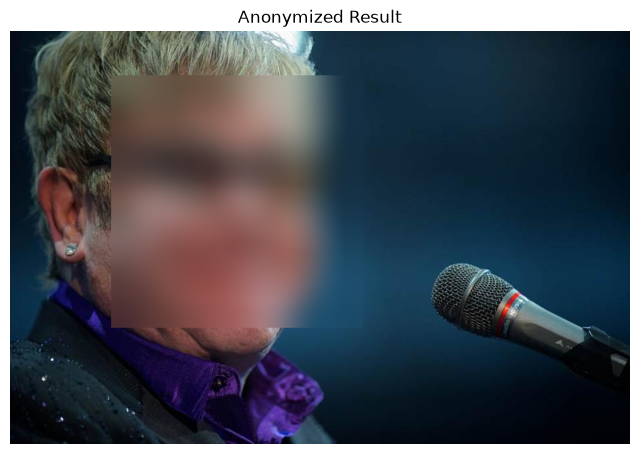

In [28]:
# Find an image where at least one face was detected
# and there are no false negatives.

successful_examples = []

for image_name, metrics in image_metrics.items():

    if (
        metrics["true_positives"] > 0
        and metrics["false_negatives"] == 0
    ):
        successful_examples.append(image_name)

print(f"Successful examples available: {len(successful_examples)}")

if successful_examples:
    successful_image = successful_examples[0]
    print(f"Selected example: {successful_image}")

    visualize_evaluation_result(successful_image)

Failure examples available: 176
Selected failure case: 11--Meeting/11_Meeting_Meeting_11_Meeting_Meeting_11_287.jpg


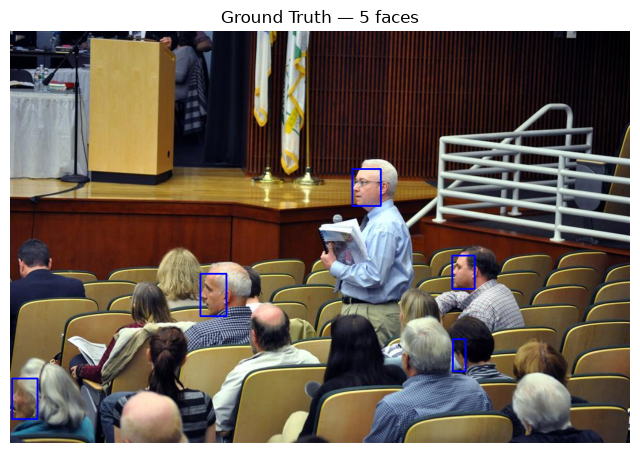

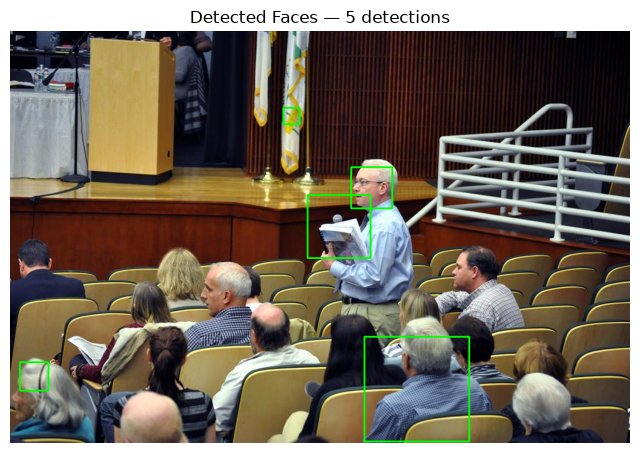

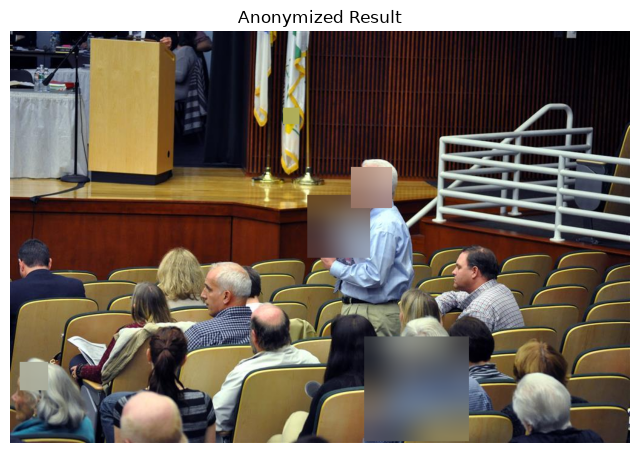

In [29]:
# Find an image where the detector missed at least one face

failure_examples = []

for image_name, metrics in image_metrics.items():

    if metrics["false_negatives"] > 0:
        failure_examples.append(image_name)

print(f"Failure examples available: {len(failure_examples)}")

if failure_examples:
    failure_image = failure_examples[0]
    print(f"Selected failure case: {failure_image}")

    visualize_evaluation_result(failure_image)

## Evaluation Summary

The evaluation demonstrates that the system can successfully detect and anonymize faces in a range of real-world images.

The Haar Cascade detector achieves reasonable precision but substantially lower recall on the WIDER FACE validation subset. The results indicate that the approach works best for relatively clear and simple facial scenes and becomes less reliable in crowded or difficult images.

This evaluation establishes a baseline for the project rather than claiming production-level face detection performance.

The main limitation is the Haar Cascade detector itself. A future version could replace it with a modern deep-learning-based face detector to improve robustness, particularly for small, occluded, and non-frontal faces.

In [30]:
print("=" * 60)
print("FACE BLURRING EVALUATION SUMMARY")
print("=" * 60)

print(f"Evaluation images: {len(detection_results)}")
print(f"True positives:    {total_true_positives}")
print(f"False positives:   {total_false_positives}")
print(f"False negatives:   {total_false_negatives}")

print()
print(f"Precision: {precision * 100:.2f}%")
print(f"Recall:    {recall * 100:.2f}%")
print(f"F1-score:  {f1_score * 100:.2f}%")

print()
print(f"Average detection time: {average_time * 1000:.2f} ms")
print(f"Median detection time:  {median_time * 1000:.2f} ms")

print()
print("Evaluation completed.")

FACE BLURRING EVALUATION SUMMARY
Evaluation images: 200
True positives:    1319
False positives:   1328
False negatives:   7922

Precision: 49.83%
Recall:    14.27%
F1-score:  22.19%

Average detection time: 188.98 ms
Median detection time:  174.06 ms

Evaluation completed.
